###

In [1]:
import sys
sys.path.append('/home/maria/Documents/projects/anomaly_detection_vehicles')

In [303]:
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

class CustomTrainDataset(Dataset):

    def __init__(self, image_dir, anomaly_source_dir, resize_shape=(256, 256)):
        """
        Args:
            image_dir (string): Directory with all the training images.
            anomaly_source_dir (string): Directory with images to introduce anomalies.
            resize_shape (tuple): Desired image size (height, width).
        """
        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape

        # Collect all image paths (supporting .png, .jpg, .jpeg)
        self.image_paths = sorted(glob.glob(f"{image_dir}/*/*.png") + glob.glob(f"{image_dir}/*/*.jpg") + glob.glob(f"{image_dir}/*/*.jpeg"))
        self.anomaly_source_paths = sorted(glob.glob(f"{anomaly_source_dir}/*/*.jpg") + glob.glob(f"{anomaly_source_dir}/*/*.png"))

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        # Define a set of augmentations
        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        return aug

    def augment_image(self, image, anomaly_source_path):
        aug = self.randAugmenter()
        perlin_scale = 6
        min_perlin_scale = 0

        # Load and resize the anomaly source image
        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)
        #anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))

        anomaly_img_augmented = aug(image=anomaly_source_img)

        # Generate Perlin noise
        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_noise = rand_perlin_2d_np((self.resize_shape[0], self.resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = self.rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        no_anomaly = torch.rand(1).item()
        if no_anomaly > 0.5:
            return image.astype(np.float32), np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0], dtype=np.float32)
        else:
            augmented_image = augmented_image.astype(np.float32)
            mask = perlin_thr.astype(np.float32)
            augmented_image = mask * augmented_image + (1 - mask) * image
            has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
            return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

    def transform_image(self, image_path, anomaly_source_path):
        # Load and resize the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #filename = "/home/maria/Documents/projects/anomaly_detection_vehicles/TEST_FIELD_1_/visualisations/ORIGINAL.png"
        #plt.imsave(filename, image)
        #image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        # Apply random rotation
        if torch.rand(1).item() > 0.7:
            image = self.rot(image=image)

        # Normalize the image
        image = image.astype(np.float32) / 255.0

        # Augment the image and generate the anomaly mask
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path)

        print("before")
        print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)

        # Transpose to (C, H, W) format
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        print("after")
        print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)

        return image, augmented_image, anomaly_mask, has_anomaly

    def __getitem__(self, idx):
        # Randomly select an image and an anomaly source image
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()

        image_path = self.image_paths[idx]
        anomaly_source_path = self.anomaly_source_paths[anomaly_source_idx]

        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(image_path, anomaly_source_path)

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

before
(256, 256, 3) (256, 256, 1) (1,)
after
(3, 256, 256) (1, 256, 256) (1,)
<class 'numpy.ndarray'> 1.0 0.023529412
<class 'numpy.ndarray'> 1.0 0.023529412
<class 'numpy.ndarray'> 0.0 0.0
(256, 256, 3)


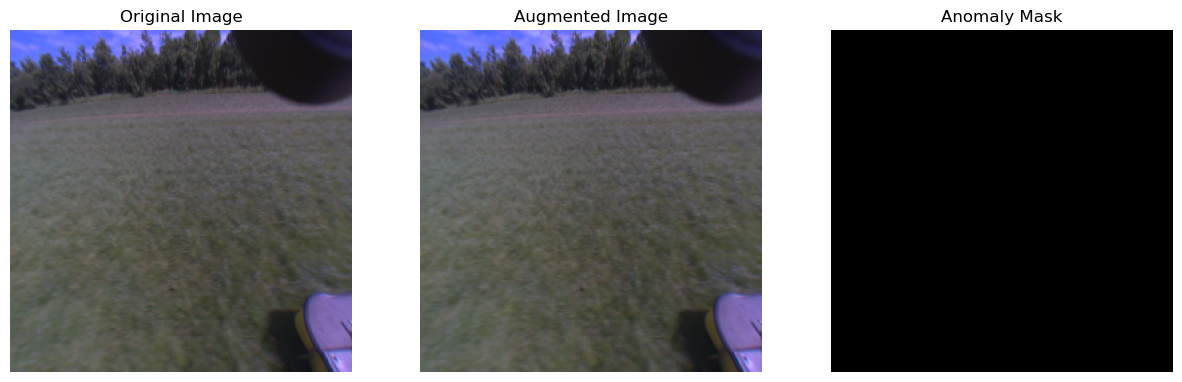

'\nbefore\n(256, 512, 3) (256, 512, 1) (1,)\nafter\n(3, 256, 512) (1, 256, 512) (1,)\n(256, 512, 3)\n'

In [304]:
import matplotlib.pyplot as plt

image_dir = '/home/maria/Documents/dataset_splited/agco_dataset/train/'
anomaly_source_dir = '/home/maria/Documents/datasets/dtd/images/'

# Initialize the dataset with the desired method ('perlin' or 'cutpaste')
dataset_perlin = CustomTrainDataset(image_dir=image_dir, anomaly_source_dir=anomaly_source_dir)
#dataset_cutpaste = FieldTrainDataset(image_dir=image_dir, anomaly_source_dir=anomaly_source_dir, method='cutpaste')

# Function to visualize a dataset sample
def visualize_sample(dataset, method):
    # Get a random sample
    sample = dataset[random.randint(0, len(dataset) - 1)]

    # Extract data from the sample
    image = sample['image'].transpose(1, 2, 0)
    print(type(image), image.max(), image.min())
    augmented_image = sample['augmented_image'].transpose(1, 2, 0)
    print(type(augmented_image), augmented_image.max(), augmented_image.min())
    anomaly_mask = sample['anomaly_mask'].transpose(1, 2, 0).squeeze()
    print(type(anomaly_mask), anomaly_mask.max(), anomaly_mask.min())

    print(augmented_image.shape)
    
    # Plot the results
    plt.figure(figsize=(15, 5))

    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    # Augmented Image
    plt.subplot(1, 3, 2)
    plt.imshow(augmented_image)
    plt.title("Augmented Image")
    plt.axis('off')

    # Anomaly Mask
    plt.subplot(1, 3, 3)
    plt.imshow(anomaly_mask, cmap='gray')
    plt.title("Anomaly Mask")
    plt.axis('off')

    plt.show()

# Visualize samples for both Perlin and CutPaste methods
visualize_sample(dataset_perlin, method='Perlin')
#visualize_sample(dataset_cutpaste, method='CutPaste')

"""
before
(256, 512, 3) (256, 512, 1) (1,)
after
(3, 256, 512) (1, 256, 512) (1,)
(256, 512, 3)
"""

### THIS IS WORKING DO NOT DELETE IT 

In [265]:
import os
import numpy as np
from torch.utils.data import Dataset
import torch
import cv2
import glob
import random
import imgaug.augmenters as iaa # traditional argumentations
from perlin import rand_perlin_2d_np 

class FieldTrainDataset(Dataset):

    def __init__(self, image_dir, resize_shape=(256, 256*2), method='perlin', anomaly_source_dir=None):

        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape
        self.method = method

        if (self.anomaly_source_dir is None) or (self.method != 'perlin'):
            self.anomaly_source_dir = image_dir

        self.image_paths = sorted(glob.glob(f"{self.image_dir}/*/*.png") + glob.glob(f"{self.image_dir}/*/*.jpg") + glob.glob(f"{self.image_dir}/*/*.jpeg")) 
        print(self.image_paths[0])
        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        self.anomaly_source_paths = sorted(glob.glob(f"{self.anomaly_source_dir}/*/*.png") + glob.glob(f"{self.anomaly_source_dir}/*/*.jpg") + glob.glob(f"{self.anomaly_source_dir}/*/*.jpeg")) 
        print(self.anomaly_source_paths[0])
        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        # TODO: add which trad_da where selected
        
        return aug
    
    def perlin(self, anomaly_img_augmented, image):

        perlin_scale = 6
        min_perlin_scale = 0

        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        
        perlin_noise = rand_perlin_2d_np((self.resize_shape[0], self.resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = self.rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        return augmented_image, perlin_thr

    def cut_paste_augment(self, source, destination):

        augmented_image = destination.copy()
        source = source.astype(np.float32)/255.
        plt.imshow(source)
        height, width, _ = destination.shape
        mask = np.zeros((height, width), dtype=np.uint8)  
        num_patches = random.randint(1, 5)

        for _ in range(num_patches):
            use_scar = random.choice([True, False])

            if use_scar:
                patch_width = random.randint(10, 40)
                patch_height = random.randint(50, 200)

                source_top_left_x = random.randint(0, source.shape[1] - patch_width)
                source_top_left_y = random.randint(0, source.shape[0] - patch_height)
                patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

                angle = random.uniform(0, 360)
                center = (patch_width // 2, patch_height // 2)
                rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
                patch = cv2.warpAffine(patch, rotation_matrix, (patch_width, patch_height))
            else:
                patch_area_ratio = random.uniform(0.02, 0.15)
                aspect_ratio = random.uniform(0.3, 3.3)
                patch_width = int(np.sqrt(patch_area_ratio * width * height * aspect_ratio))
                patch_height = int(np.sqrt(patch_area_ratio * width * height / aspect_ratio))

                patch_width = min(patch_width, width)
                patch_height = min(patch_height, height)

                source_top_left_x = random.randint(0, source.shape[1] - patch_width)
                source_top_left_y = random.randint(0, source.shape[0] - patch_height)
                patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

                patch = cv2.flip(patch, 1) if random.random() > 0.5 else patch

            patch_height, patch_width = patch.shape[:2]

            paste_x = random.randint(0, width - patch_width)
            paste_y = random.randint(0, height - patch_height)

            if paste_y + patch_height > augmented_image.shape[0]:
                patch_height = augmented_image.shape[0] - paste_y
            if paste_x + patch_width > augmented_image.shape[1]:
                patch_width = augmented_image.shape[1] - paste_x

            patch = patch[:patch_height, :patch_width]

            augmented_image[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = patch
            
            mask[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = 1

        return augmented_image, np.expand_dims(mask, axis=2)
    
    def augment_image(self, image, anomaly_source_path, method):
        
        aug = self.randAugmenter()

        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB) 
        anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))

        anomaly_img_augmented = aug(image=anomaly_source_img)

        if method == 'perlin':
            augmented_image, perlin_thr = self.perlin(anomaly_img_augmented, image)
        
            # apply the ano_da
            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                return image.astype(np.float32), np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)
                mask = perlin_thr.astype(np.float32)
                print("mask")
                print(mask.shape)
                augmented_image = mask * augmented_image + (1 - mask) * image
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)
        
        elif method == 'cutpaste':
            augmented_image, mask = self.cut_paste_augment(anomaly_img_augmented, image)

            no_anomaly = torch.rand(1).item()
            if no_anomaly > 0.5:
                return image.astype(np.float32), np.zeros_like(mask, dtype=np.float32), np.array([0.0], dtype=np.float32)
            else:
                augmented_image = augmented_image.astype(np.float32)
                mask = mask.astype(np.float32)
                augmented_image = mask * augmented_image + (1 - mask) * image
                has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
                return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

    def transform_image(self, image_path, anomaly_source_path, method):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        if torch.rand(1).item() > 0.7:
            image = self.rot(image=image)

        image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path, method)
        
        print("before")
        print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)
        
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        print("after")
        print(augmented_image.shape, anomaly_mask.shape, has_anomaly.shape)
        
        return image, augmented_image, anomaly_mask, has_anomaly
        

    def __getitem__(self, idx):
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()
        
        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(self.image_paths[idx],
                                                                           self.anomaly_source_paths[anomaly_source_idx], self.method)
        
        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_26_18_203.png
/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_26_18_203.png
before
(256, 512, 3) (256, 512, 1) (1,)
after
(3, 256, 512) (1, 256, 512) (1,)
<class 'numpy.ndarray'> 1.0 0.019607844
<class 'numpy.ndarray'> 1.0 0.0
<class 'numpy.ndarray'> 1.0 0.0
(256, 512, 3)


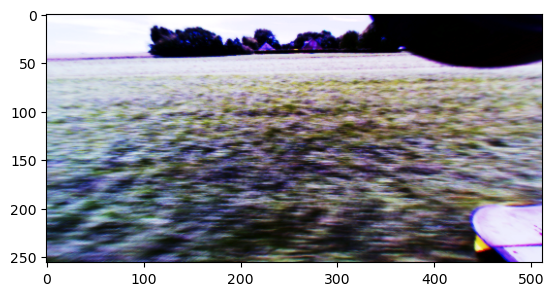

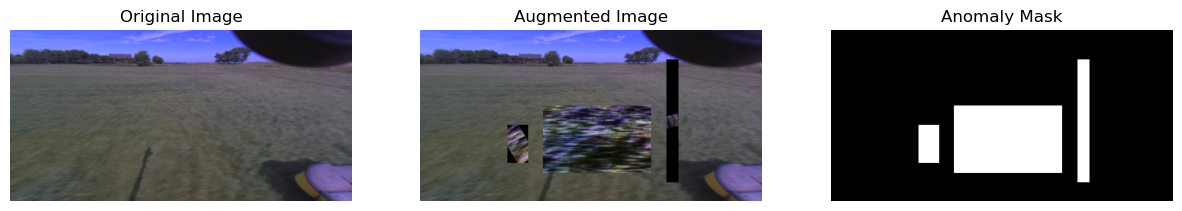

'\nbefore\n(256, 512, 3) (256, 512, 1) (1,)\nafter\n(3, 256, 512) (1, 256, 512) (1,)\n(256, 512, 3)\n'

In [306]:
import matplotlib.pyplot as plt

image_dir = '/home/maria/Documents/dataset_splited/agco_dataset/train/'
anomaly_source_dir = '/home/maria/Documents/datasets/dtd/images/'

# Initialize the dataset with the desired method ('perlin' or 'cutpaste')
dataset_perlin = FieldTrainDataset(image_dir=image_dir, anomaly_source_dir=None, method='cutpaste')
#dataset_cutpaste = FieldTrainDataset(image_dir=image_dir, anomaly_source_dir=anomaly_source_dir, method='cutpaste')

# Function to visualize a dataset sample
def visualize_sample(dataset, method):
    # Get a random sample
    sample = dataset[random.randint(0, len(dataset) - 1)]

    # Extract data from the sample
    image = sample['image'].transpose(1, 2, 0)
    print(type(image), image.max(), image.min())
    augmented_image = sample['augmented_image'].transpose(1, 2, 0)
    print(type(augmented_image), augmented_image.max(), augmented_image.min())
    anomaly_mask = sample['anomaly_mask'].transpose(1, 2, 0).squeeze()
    print(type(anomaly_mask), anomaly_mask.max(), anomaly_mask.min())

    print(augmented_image.shape)
    
    # Plot the results
    plt.figure(figsize=(15, 5))

    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    # Augmented Image
    plt.subplot(1, 3, 2)
    plt.imshow(augmented_image)
    plt.title("Augmented Image")
    plt.axis('off')

    # Anomaly Mask
    plt.subplot(1, 3, 3)
    plt.imshow(anomaly_mask, cmap='gray')
    plt.title("Anomaly Mask")
    plt.axis('off')

    plt.show()

# Visualize samples for both Perlin and CutPaste methods
visualize_sample(dataset_perlin, method='Perlin')
#visualize_sample(dataset_cutpaste, method='CutPaste')

"""
before
(256, 512, 3) (256, 512, 1) (1,)
after
(3, 256, 512) (1, 256, 512) (1,)
(256, 512, 3)
"""

In [22]:
class CustomTrainDataset(Dataset):

    def __init__(self, image_dir, anomaly_source_dir, resize_shape=(256, 256)):
        """
        Args:
            image_dir (string): Directory with all the training images.
            anomaly_source_dir (string): Directory with images to introduce anomalies.
            resize_shape (tuple): Desired image size (height, width).
        """
        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape

        # Collect all image paths (supporting .png, .jpg, .jpeg)
        self.image_paths = sorted(glob.glob(f"{image_dir}/*/*.png") + glob.glob(f"{image_dir}/*/*.jpg") + glob.glob(f"{image_dir}/*/*.jpeg"))
        self.anomaly_source_paths = sorted(glob.glob(f"{anomaly_source_dir}/*/*.jpg") + glob.glob(f"{anomaly_source_dir}/*/*.png"))

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        # Define a set of augmentations
        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        return aug

    def augment_image(self, image, anomaly_source_path):
        aug = self.randAugmenter()
        perlin_scale = 6
        min_perlin_scale = 0

        # Load and resize the anomaly source image
        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)
        #anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))

        anomaly_img_augmented = aug(image=anomaly_source_img)

        # Generate Perlin noise
        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_noise = rand_perlin_2d_np((self.resize_shape[0], self.resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = self.rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        no_anomaly = torch.rand(1).item()
        if no_anomaly > 0.5:
            return image.astype(np.float32), np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0], dtype=np.float32)
        else:
            augmented_image = augmented_image.astype(np.float32)
            mask = perlin_thr.astype(np.float32)
            augmented_image = mask * augmented_image + (1 - mask) * image
            has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
            return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

    def transform_image(self, image_path, anomaly_source_path):
        # Load and resize the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #filename = "/home/maria/Documents/projects/anomaly_detection_vehicles/TEST_FIELD_1_/visualisations/ORIGINAL.png"
        #plt.imsave(filename, image)
        #image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        # Apply random rotation
        if torch.rand(1).item() > 0.7:
            image = self.rot(image=image)

        # Normalize the image
        image = image.astype(np.float32) / 255.0

        # Augment the image and generate the anomaly mask
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path)

        # Transpose to (C, H, W) format
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        return image, augmented_image, anomaly_mask, has_anomaly

    def __getitem__(self, idx):
        # Randomly select an image and an anomaly source image
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()

        image_path = self.image_paths[idx]
        anomaly_source_path = self.anomaly_source_paths[anomaly_source_idx]

        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(image_path, anomaly_source_path)

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

In [78]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import imgaug.augmenters as iaa
import glob

class CustomTrainDataset(Dataset):

    def __init__(self, image_dir, anomaly_source_dir, resize_shape=(256, 256)):
        """
        Args:
            image_dir (string): Directory with all the training images.
            anomaly_source_dir (string): Directory with images to introduce anomalies.
            resize_shape (tuple): Desired image size (height, width).
        """
        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape

        # Collect all image paths (supporting .png, .jpg, .jpeg)
        self.image_paths = sorted(glob.glob(f"{image_dir}/*/*.png") + glob.glob(f"{image_dir}/*/*.jpg") + glob.glob(f"{image_dir}/*/*.jpeg"))
        self.anomaly_source_paths = sorted(glob.glob(f"{anomaly_source_dir}/*/*.jpg") + glob.glob(f"{anomaly_source_dir}/*/*.png"))

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        # Define a set of augmentations
        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        print(aug_indices)
        return aug

    def augment_image(self, image, anomaly_source_path):
        # Load and resize the anomaly source image
        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)
        anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))

        # Apply random augmentations
        aug = self.randAugmenter()
        augmented_image = aug(image=anomaly_source_img)

        # For simplicity, assume the augmented image introduces an anomaly
        has_anomaly = np.array([0.0], dtype=np.float32)
        anomaly_mask = np.zeros((self.resize_shape[0], self.resize_shape[1], 1), dtype=np.float32)

        return augmented_image, anomaly_mask, has_anomaly

    def transform_image(self, image_path, anomaly_source_path):
        # Load and resize the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        # Apply random rotation
        if torch.rand(1).item() > 0.7:
            image = self.rot(image=image)

        # Normalize the image
        image = image.astype(np.float32) / 255.0

        # Augment the image and generate the anomaly mask
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path=image_path)

        # Transpose to (C, H, W) format
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        return image, augmented_image, anomaly_mask, has_anomaly

    def __getitem__(self, idx):
        # Randomly select an image and an anomaly source image
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()

        image_path = self.image_paths[idx]
        anomaly_source_path = self.anomaly_source_paths[anomaly_source_idx]

        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(image_path, anomaly_source_path)

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample


In [79]:
#configurations

train_image_path = '/home/maria/Documents/dataset_splited/agco_dataset/train/'
anomaly_source_path = '/home/maria/Documents/datasets/dtd/images/'
resize_image = (256, 256*2)

In [ ]:
class CustomTrainDataset(Dataset):

    def __init__(self, image_dir, anomaly_source_dir, resize_shape=(256, 256)):

        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape

        self.image_paths = sorted(glob.glob(f"{image_dir}/*/*.png") + glob.glob(f"{image_dir}/*/*.jpg") + glob.glob(f"{image_dir}/*/*.jpeg"))
        self.anomaly_source_paths = sorted(glob.glob(f"{anomaly_source_dir}/*/*.jpg") + glob.glob(f"{anomaly_source_dir}/*/*.png"))

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        # Define a set of augmentations
        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45)),
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)

        selected_augs = [self.augmenters[i] for i in aug_indices]
        aug_names = [aug.__class__.__name__ for aug in selected_augs]
        aug = iaa.Sequential(selected_augs)

        return aug, aug_names

    def augment_image(self, image):

        if torch.rand(1).item() > 0.5:
            aug, aug_names = self.randAugmenter()
        else:
            aug = iaa.Sequential([])
            aug_names = ["No augmentations applied"]
            #print("No augmentations applied.")

        # Convert image to uint8 before applying augmentations
        image_uint8 = (image * 255).clip(0, 255).astype(np.uint8)

        # Apply augmentations
        augmented_image = aug(image=image_uint8)

        # Convert augmented image back to float32
        augmented_image = augmented_image.astype(np.float32) / 255.0

        return augmented_image, aug_names

    def transform_image(self, image_path):
        # Load and resize the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        do_aug_orig = torch.rand(1).numpy()[0] > 0.7
        if do_aug_orig:
            image = self.rot(image=image)

        # Apply random rotation and flipping
        #if torch.rand(1).item() > 0.5:
        #    augmenter = iaa.Sequential([
        #        iaa.Fliplr(0.5),
        #        iaa.Affine(rotate=(-90, 90))
        #    ])
        #    print("Applied augmentations: Fliplr, Affine")
        #    image = augmenter(image=image)
        #else:
        #    print("No rotation or flipping applied.")

        # Normalize the image
        image = image.astype(np.float32) / 255.0

        # Augment the image
        augmented_image, aug_names = self.augment_image(image)

        # Create an anomaly mask with all values set to 0
        anomaly_mask = np.zeros((self.resize_shape[0], self.resize_shape[1], 1), dtype=np.float32)

        # Transpose to (C, H, W) format
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        return image, augmented_image, anomaly_mask, np.array([0.0], dtype=np.float32), aug_names

    def __getitem__(self, idx):
        # Randomly select an image
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        image_path = self.image_paths[idx]

        image, augmented_image, anomaly_mask, has_anomaly, aug_names = self.transform_image(image_path)

        #print(f"Image {idx} augmentations: {', '.join(aug_names)}")

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

In [75]:
import cv2
import numpy as np
import random
import torch

class DataAugmentor:
    def __init__(self, resize_shape=(256, 256)):
        self.resize_shape = resize_shape

    def randAugmenter(self):
        # Placeholder for a random augmentation function
        return lambda image: image

    def rot(self, image):
        # Placeholder for a rotation function
        return image

    def cut_paste_augment(self, source, destination, num_patches=1, include_scar=True):
        """Apply CutPaste augmentation."""
        augmented_image = destination.copy()
        height, width, _ = destination.shape
        mask = np.zeros((height, width), dtype=np.uint8)

        for _ in range(num_patches):
            use_scar = include_scar and random.choice([True, False])

            if use_scar:
                patch_width = random.randint(10, 40)
                patch_height = random.randint(50, 200)
            else:
                patch_area_ratio = random.uniform(0.02, 0.15)
                aspect_ratio = random.uniform(0.3, 3.3)
                patch_width = int(np.sqrt(patch_area_ratio * width * height * aspect_ratio))
                patch_height = int(np.sqrt(patch_area_ratio * width * height / aspect_ratio))

                patch_width = min(patch_width, width)
                patch_height = min(patch_height, height)

            source_top_left_x = random.randint(0, source.shape[1] - patch_width)
            source_top_left_y = random.randint(0, source.shape[0] - patch_height)
            patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

            if use_scar:
                angle = random.uniform(0, 360)
                center = (patch_width // 2, patch_height // 2)
                rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
                patch = cv2.warpAffine(patch, rotation_matrix, (patch_width, patch_height))

            patch_height, patch_width = patch.shape[:2]

            paste_x = random.randint(0, width - patch_width)
            paste_y = random.randint(0, height - patch_height)

            patch = patch[:patch_height, :patch_width]
            augmented_image[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = patch
            mask[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = 1

        return augmented_image, mask

    def augment_image(self, image, anomaly_source_path):
        aug = self.randAugmenter()

        # Load and resize the anomaly source image
        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)
        anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))
        
        # Apply random augmentation to the anomaly source image
        anomaly_img_augmented = aug(image=anomaly_source_img)
        
        # Apply CutPaste augmentation
        augmented_image, mask = self.cut_paste_augment(anomaly_img_augmented, image, num_patches=5, include_scar=True)

        no_anomaly = torch.rand(1).item()
        if no_anomaly > 0.5:
            return image.astype(np.float32), np.zeros_like(mask, dtype=np.float32), np.array([0.0], dtype=np.float32)
        else:
            augmented_image = augmented_image.astype(np.float32)
            mask = mask.astype(np.float32)
            augmented_image = mask[..., None] * augmented_image + (1 - mask[..., None]) * image
            has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
            return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)



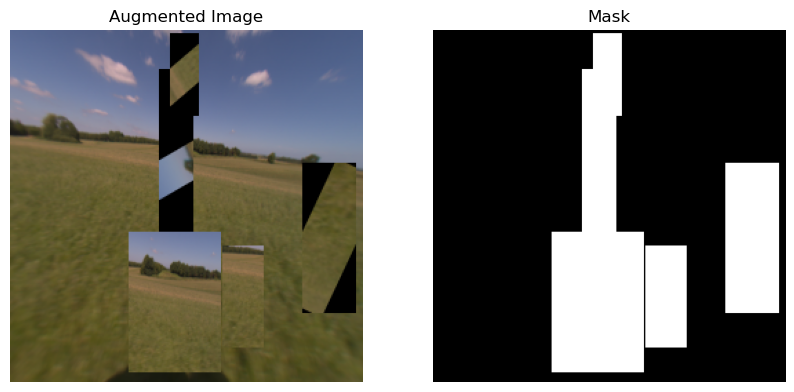

In [77]:
# Example usage
if __name__ == "__main__":
    augmentor = DataAugmentor(resize_shape=(256, 256))

    image_path = '/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_lucid_490_image_raw_2024_06_25_13_48_29_802.png'
    anomaly_source_path = '/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_lucid_490_image_raw_2024_06_25_13_48_29_802.png'

    # Load the main image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (256, 256))

    # Perform augmentation
    augmented_image, mask, has_anomaly = augmentor.augment_image(image, anomaly_source_path)

    # Display results
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Augmented Image")
    plt.imshow(augmented_image.astype(np.uint8))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

    plt.show()

In [ ]:
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

class CustomTrainDataset(Dataset):

    def __init__(self, image_dir, anomaly_source_dir, resize_shape=(256, 256)):
        """
        Args:
            image_dir (string): Directory with all the training images.
            anomaly_source_dir (string): Directory with images to introduce anomalies.
            resize_shape (tuple): Desired image size (height, width).
        """
        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape

        # Collect all image paths (supporting .png, .jpg, .jpeg)
        self.image_paths = sorted(glob.glob(f"{image_dir}/*/*.png") + glob.glob(f"{image_dir}/*/*.jpg") + glob.glob(f"{image_dir}/*/*.jpeg"))
        self.anomaly_source_paths = sorted(glob.glob(f"{anomaly_source_dir}/*/*.jpg") + glob.glob(f"{anomaly_source_dir}/*/*.png"))

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        # Define a set of augmentations
        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45))
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[i] for i in aug_indices])
        return aug

    def augment_image(self, image, anomaly_source_path):
        aug = self.randAugmenter()
        perlin_scale = 6
        min_perlin_scale = 0

        # Load and resize the anomaly source image
        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)
        #anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        anomaly_source_img = cv2.resize(anomaly_source_img, (self.resize_shape[1], self.resize_shape[0]))

        anomaly_img_augmented = aug(image=anomaly_source_img)

        # Generate Perlin noise
        perlin_scalex = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_scaley = 2 ** torch.randint(min_perlin_scale, perlin_scale, (1,)).item()
        perlin_noise = rand_perlin_2d_np((self.resize_shape[0], self.resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = self.rot(image=perlin_noise)

        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, 1, 0).astype(np.float32)
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).item() * 0.8
        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * perlin_thr

        no_anomaly = torch.rand(1).item()
        if no_anomaly > 0.5:
            return image.astype(np.float32), np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0], dtype=np.float32)
        else:
            augmented_image = augmented_image.astype(np.float32)
            mask = perlin_thr.astype(np.float32)
            augmented_image = mask * augmented_image + (1 - mask) * image
            has_anomaly = 1.0 if np.sum(mask) > 0 else 0.0
            return augmented_image, mask, np.array([has_anomaly], dtype=np.float32)

    def transform_image(self, image_path, anomaly_source_path):
        # Load and resize the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #filename = "/home/maria/Documents/projects/anomaly_detection_vehicles/TEST_FIELD_1_/visualisations/ORIGINAL.png"
        #plt.imsave(filename, image)
        #image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        # Apply random rotation
        if torch.rand(1).item() > 0.7:
            image = self.rot(image=image)

        # Normalize the image
        image = image.astype(np.float32) / 255.0

        # Augment the image and generate the anomaly mask
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path)

        # Transpose to (C, H, W) format
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        return image, augmented_image, anomaly_mask, has_anomaly

    def __getitem__(self, idx):
        # Randomly select an image and an anomaly source image
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()

        image_path = self.image_paths[idx]
        anomaly_source_path = self.anomaly_source_paths[anomaly_source_idx]

        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(image_path, anomaly_source_path)

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample

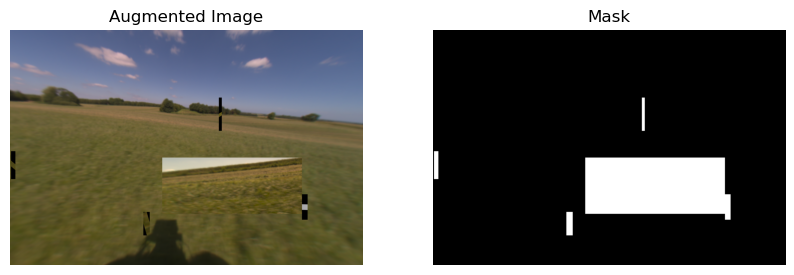

In [32]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

def cut_paste_augment(source, destination, num_patches=1, include_scar=True):

    augmented_image = destination.copy()
    height, width, _ = destination.shape
    mask = np.zeros((height, width), dtype=np.uint8)  

    for _ in range(num_patches):
        use_scar = include_scar and random.choice([True, False])

        if use_scar:
            patch_width = random.randint(10, 40)
            patch_height = random.randint(50, 200)

            source_top_left_x = random.randint(0, source.shape[1] - patch_width)
            source_top_left_y = random.randint(0, source.shape[0] - patch_height)
            patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

            angle = random.uniform(0, 360)
            center = (patch_width // 2, patch_height // 2)
            rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
            patch = cv2.warpAffine(patch, rotation_matrix, (patch_width, patch_height))
        else:
            patch_area_ratio = random.uniform(0.02, 0.15)
            aspect_ratio = random.uniform(0.3, 3.3)
            patch_width = int(np.sqrt(patch_area_ratio * width * height * aspect_ratio))
            patch_height = int(np.sqrt(patch_area_ratio * width * height / aspect_ratio))

            patch_width = min(patch_width, width)
            patch_height = min(patch_height, height)

            source_top_left_x = random.randint(0, source.shape[1] - patch_width)
            source_top_left_y = random.randint(0, source.shape[0] - patch_height)
            patch = source[source_top_left_y:source_top_left_y + patch_height, source_top_left_x:source_top_left_x + patch_width]

            patch = cv2.flip(patch, 1) if random.random() > 0.5 else patch

        patch_height, patch_width = patch.shape[:2]

        paste_x = random.randint(0, width - patch_width)
        paste_y = random.randint(0, height - patch_height)

        if paste_y + patch_height > augmented_image.shape[0]:
            patch_height = augmented_image.shape[0] - paste_y
        if paste_x + patch_width > augmented_image.shape[1]:
            patch_width = augmented_image.shape[1] - paste_x

        patch = patch[:patch_height, :patch_width]

        augmented_image[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = patch
        
        mask[paste_y:paste_y + patch_height, paste_x:paste_x + patch_width] = 1

    return augmented_image, mask

if __name__ == "__main__":

    source = cv2.imread('/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_lucid_490_image_raw_2024_06_25_15_11_02_602.png')
    source = cv2.cvtColor(source, cv2.COLOR_BGR2RGB)

    destination = cv2.imread('/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_lucid_490_image_raw_2024_06_25_13_48_29_802.png')
    destination = cv2.cvtColor(destination, cv2.COLOR_BGR2RGB)

    # Apply CutPaste augmentation
    augmented_image, mask = cut_paste_augment(source, destination, num_patches=5, include_scar=True)

    # Display the augmented image and mask
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Augmented Image")
    plt.imshow(augmented_image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

    plt.show()

In [80]:
dataset = CustomTrainDataset(image_dir=train_image_path, anomaly_source_dir=anomaly_source_path, resize_shape=resize_image)

In [86]:
# Get a sample from the dataset
sample = dataset[5]

image = sample['image']  # Original image
augmented_image = sample['augmented_image']  # Image with anomalies
anomaly_mask = sample['anomaly_mask']  # Binary anomaly mask
has_anomaly = sample['has_anomaly']  # Flag indicating if there's an anomaly

# Convert tensors to NumPy arrays for visualization
image = image.transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
augmented_image = augmented_image.transpose(1, 2, 0)
anomaly_mask = anomaly_mask.transpose(1, 2, 0)

[5 3 0]


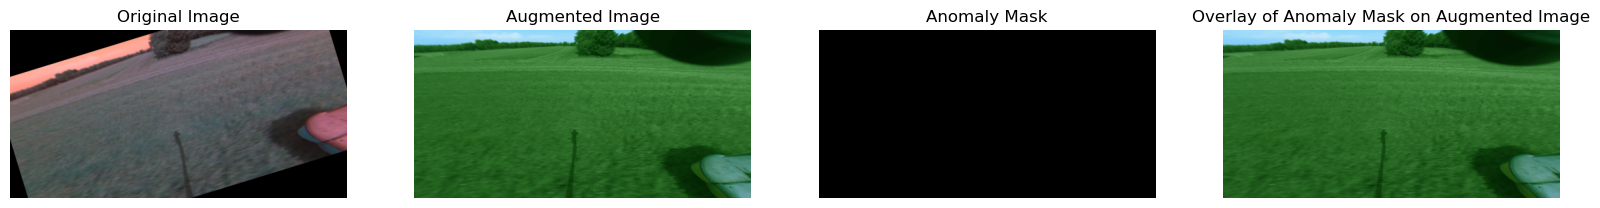

In [87]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original Image
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Augmented Image with Anomalies
axes[1].imshow(augmented_image)
axes[1].set_title("Augmented Image")
axes[1].axis("off")

# Anomaly Mask
axes[2].imshow(anomaly_mask.squeeze(), cmap='gray')
axes[2].set_title("Anomaly Mask")
axes[2].axis("off")

# Overlay Anomaly Mask on Augmented Image
overlay = augmented_image.copy()
overlay[anomaly_mask.squeeze() > 0] = [1.0, 0, 0]  # Red color for anomaly
axes[3].imshow(overlay)
axes[3].set_title("Overlay of Anomaly Mask on Augmented Image")
axes[3].axis("off")

plt.show()

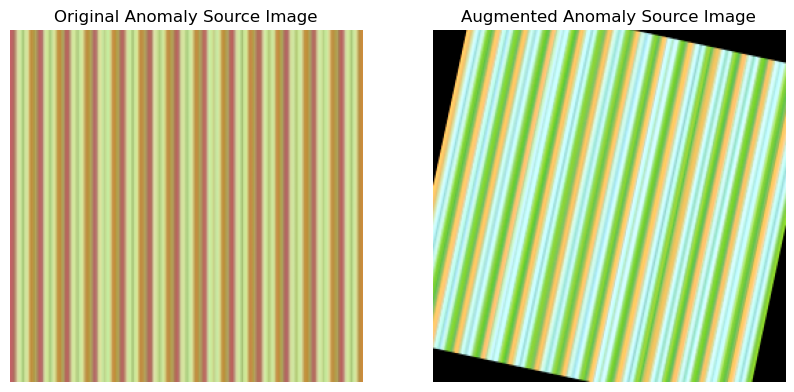

In [38]:
from imgaug.augmenters import Sequential
import cv2

# Get a random anomaly source image path
anomaly_source_path = dataset.anomaly_source_paths[0]

# Load the anomaly source image
anomaly_source_img = cv2.imread(anomaly_source_path)
anomaly_source_img = cv2.cvtColor(anomaly_source_img, cv2.COLOR_BGR2RGB)
anomaly_source_img_resized = cv2.resize(anomaly_source_img, (256, 256))

# Apply random augmentations
aug = dataset.randAugmenter()
augmented_anomaly_img = aug(image=anomaly_source_img_resized)

# Plot original and augmented anomaly source images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(anomaly_source_img_resized)
plt.title("Original Anomaly Source Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_anomaly_img)
plt.title("Augmented Anomaly Source Image")
plt.axis("off")

plt.show()

In [ ]:
import os
import numpy as np
from torch.utils.data import Dataset
import torch
import cv2
import glob
import imgaug.augmenters as iaa
from perlin import rand_perlin_2d_np

class MVTecDRAEMTestDataset(Dataset):

    def __init__(self, root_dir, resize_shape=None):
        self.root_dir = root_dir
        self.images = sorted(glob.glob(root_dir+"/*/*.png"))
        self.resize_shape=resize_shape

    def __len__(self):
        return len(self.images)

    def transform_image(self, image_path, mask_path):
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if mask_path is not None:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            mask = np.zeros((image.shape[0],image.shape[1]))
        if self.resize_shape != None:
            image = cv2.resize(image, dsize=(self.resize_shape[1], self.resize_shape[0]))
            mask = cv2.resize(mask, dsize=(self.resize_shape[1], self.resize_shape[0]))

        image = image / 255.0
        mask = mask / 255.0

        image = np.array(image).reshape((image.shape[0], image.shape[1], 3)).astype(np.float32)
        mask = np.array(mask).reshape((mask.shape[0], mask.shape[1], 1)).astype(np.float32)

        image = np.transpose(image, (2, 0, 1))
        mask = np.transpose(mask, (2, 0, 1))
        return image, mask

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_path = self.images[idx]
        dir_path, file_name = os.path.split(img_path)
        base_dir = os.path.basename(dir_path)
        if base_dir == 'good':
            image, mask = self.transform_image(img_path, None)
            has_anomaly = np.array([0], dtype=np.float32)
        else:
            mask_path = os.path.join(dir_path, '../../ground_truth/')
            mask_path = os.path.join(mask_path, base_dir)
            mask_file_name = file_name.split(".")[0]+"_mask.png"
            mask_path = os.path.join(mask_path, mask_file_name)
            image, mask = self.transform_image(img_path, mask_path)
            has_anomaly = np.array([1], dtype=np.float32)

        sample = {'image': image, 'has_anomaly': has_anomaly,'mask': mask, 'idx': idx}

        return sample



class MVTecDRAEMTrainDataset(Dataset):

    def __init__(self, root_dir, anomaly_source_path, resize_shape=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.root_dir = root_dir
        self.resize_shape=resize_shape

        self.image_paths = sorted(glob.glob(root_dir+"/*.png"))

        self.anomaly_source_paths = sorted(glob.glob(anomaly_source_path+"/*/*.jpg"))

        self.augmenters = [iaa.GammaContrast((0.5,2.0),per_channel=True),
                      iaa.MultiplyAndAddToBrightness(mul=(0.8,1.2),add=(-30,30)),
                      iaa.pillike.EnhanceSharpness(),
                      iaa.AddToHueAndSaturation((-50,50),per_channel=True),
                      iaa.Solarize(0.5, threshold=(32,128)),
                      iaa.Posterize(),
                      iaa.Invert(),
                      iaa.pillike.Autocontrast(),
                      iaa.pillike.Equalize(),
                      iaa.Affine(rotate=(-45, 45))
                      ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])


    def __len__(self):
        return len(self.image_paths)


    def randAugmenter(self):
        aug_ind = np.random.choice(np.arange(len(self.augmenters)), 3, replace=False)
        aug = iaa.Sequential([self.augmenters[aug_ind[0]],
                              self.augmenters[aug_ind[1]],
                              self.augmenters[aug_ind[2]]]
                             )
        return aug

    def augment_image(self, image, anomaly_source_path):
        aug = self.randAugmenter()
        
        perlin_scale = 6
        min_perlin_scale = 0
        anomaly_source_img = cv2.imread(anomaly_source_path)
        anomaly_source_img = cv2.resize(anomaly_source_img, dsize=(self.resize_shape[1], self.resize_shape[0]))

        anomaly_img_augmented = aug(image=anomaly_source_img)
        perlin_scalex = 2 ** (torch.randint(min_perlin_scale, perlin_scale, (1,)).numpy()[0])
        perlin_scaley = 2 ** (torch.randint(min_perlin_scale, perlin_scale, (1,)).numpy()[0])

        perlin_noise = rand_perlin_2d_np((self.resize_shape[0], self.resize_shape[1]), (perlin_scalex, perlin_scaley))
        perlin_noise = self.rot(image=perlin_noise)
        threshold = 0.5
        perlin_thr = np.where(perlin_noise > threshold, np.ones_like(perlin_noise), np.zeros_like(perlin_noise))
        perlin_thr = np.expand_dims(perlin_thr, axis=2)

        img_thr = anomaly_img_augmented.astype(np.float32) * perlin_thr / 255.0

        beta = torch.rand(1).numpy()[0] * 0.8

        augmented_image = image * (1 - perlin_thr) + (1 - beta) * img_thr + beta * image * (
            perlin_thr)

        no_anomaly = torch.rand(1).numpy()[0]
        if no_anomaly > 0.5:
            image = image.astype(np.float32)
            return image, np.zeros_like(perlin_thr, dtype=np.float32), np.array([0.0],dtype=np.float32)
        else:
            augmented_image = augmented_image.astype(np.float32)
            msk = (perlin_thr).astype(np.float32)
            augmented_image = msk * augmented_image + (1-msk)*image
            has_anomaly = 1.0
            if np.sum(msk) == 0:
                has_anomaly=0.0
            return augmented_image, msk, np.array([has_anomaly],dtype=np.float32)

    def transform_image(self, image_path, anomaly_source_path):
        image = cv2.imread(image_path)
        image = cv2.resize(image, dsize=(self.resize_shape[1], self.resize_shape[0]))

        do_aug_orig = torch.rand(1).numpy()[0] > 0.7
        if do_aug_orig:
            image = self.rot(image=image)

        image = np.array(image).reshape((image.shape[0], image.shape[1], image.shape[2])).astype(np.float32) / 255.0
        augmented_image, anomaly_mask, has_anomaly = self.augment_image(image, anomaly_source_path)
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        image = np.transpose(image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))
        return image, augmented_image, anomaly_mask, has_anomaly

    def __getitem__(self, idx):
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        anomaly_source_idx = torch.randint(0, len(self.anomaly_source_paths), (1,)).item()
        image, augmented_image, anomaly_mask, has_anomaly = self.transform_image(self.image_paths[idx],
                                                                           self.anomaly_source_paths[anomaly_source_idx])
        sample = {'image': image, "anomaly_mask": anomaly_mask,
                  'augmented_image': augmented_image, 'has_anomaly': has_anomaly, 'idx': idx}

        return sample

In [ ]:
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import imgaug.augmenters as iaa

class CustomTrainDataset(Dataset):
    
    def __init__(self, image_dir, anomaly_source_dir, resize_shape=(256, 256)):

        self.image_dir = image_dir
        self.anomaly_source_dir = anomaly_source_dir
        self.resize_shape = resize_shape

        self.image_paths = sorted(glob.glob(f"{image_dir}/*/*.png") + glob.glob(f"{image_dir}/*/*.jpg") + glob.glob(f"{image_dir}/*/*.jpeg"))
        self.anomaly_source_paths = sorted(glob.glob(f"{anomaly_source_dir}/*/*.jpg") + glob.glob(f"{anomaly_source_dir}/*/*.png"))

        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {image_dir}")

        if len(self.anomaly_source_paths) == 0:
            raise ValueError(f"No anomaly source images found in {anomaly_source_dir}")

        # Define a set of augmentations
        self.augmenters = [
            iaa.GammaContrast((0.5, 2.0), per_channel=True),
            iaa.MultiplyAndAddToBrightness(mul=(0.8, 1.2), add=(-30, 30)),
            iaa.pillike.EnhanceSharpness(),
            iaa.AddToHueAndSaturation((-50, 50), per_channel=True),
            iaa.Solarize(0.5, threshold=(32, 128)),
            iaa.Posterize(),
            iaa.Invert(),
            iaa.pillike.Autocontrast(),
            iaa.pillike.Equalize(),
            iaa.Affine(rotate=(-45, 45)),
        ]

        self.rot = iaa.Sequential([iaa.Affine(rotate=(-90, 90))])

    def __len__(self):
        return len(self.image_paths)

    def randAugmenter(self):
        aug_indices = np.random.choice(len(self.augmenters), 3, replace=False)
        
        selected_augs = [self.augmenters[i] for i in aug_indices]
        aug_names = [aug.__class__.__name__ for aug in selected_augs]
        aug = iaa.Sequential(selected_augs)
        
        return aug, aug_names

    def augment_image(self, image):
        
        if torch.rand(1).item() > 0.5:
            aug, aug_names = self.randAugmenter()
        else:
            aug = iaa.Sequential([])
            aug_names = ["No augmentations applied"]
            print("No augmentations applied.")
        
        # Convert image to uint8 before applying augmentations
        image_uint8 = (image * 255).clip(0, 255).astype(np.uint8)
        
        # Apply augmentations
        augmented_image = aug(image=image_uint8)
        
        # Convert augmented image back to float32
        augmented_image = augmented_image.astype(np.float32) / 255.0

        return augmented_image, aug_names

    def transform_image(self, image_path):
        # Load and resize the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.resize_shape[1], self.resize_shape[0]))

        do_aug_orig = torch.rand(1).numpy()[0] > 0.7
        if do_aug_orig:
            image = self.rot(image=image)

        # Apply random rotation and flipping
        #if torch.rand(1).item() > 0.5:
        #    augmenter = iaa.Sequential([
        #        iaa.Fliplr(0.5),
        #        iaa.Affine(rotate=(-90, 90))
        #    ])
        #    print("Applied augmentations: Fliplr, Affine")
        #    image = augmenter(image=image)
        #else:
        #    print("No rotation or flipping applied.")

        # Normalize the image
        image = image.astype(np.float32) / 255.0

        # Augment the image
        augmented_image, aug_names = self.augment_image(image)

        # Create an anomaly mask with all values set to 0
        anomaly_mask = np.zeros((self.resize_shape[0], self.resize_shape[1], 1), dtype=np.float32)

        # Transpose to (C, H, W) format
        image = np.transpose(image, (2, 0, 1))
        augmented_image = np.transpose(augmented_image, (2, 0, 1))
        anomaly_mask = np.transpose(anomaly_mask, (2, 0, 1))

        return image, augmented_image, anomaly_mask, np.array([0.0], dtype=np.float32), aug_names
    
    def __getitem__(self, idx):
        # Randomly select an image
        idx = torch.randint(0, len(self.image_paths), (1,)).item()
        image_path = self.image_paths[idx]

        image, augmented_image, anomaly_mask, has_anomaly, aug_names = self.transform_image(image_path)

        print(f"Image {idx} augmentations: {', '.join(aug_names)}")

        sample = {
            'image': image,
            'augmented_image': augmented_image,
            'anomaly_mask': anomaly_mask,
            'has_anomaly': has_anomaly,
            'idx': idx
        }

        return sample
